# Phase 11: Lévy-powered bounded factors

Computational record for `PHASE_11_LEVY.md`. The Gaussian driver of Phases 3–10 is replaced by a pure-jump Lévy driver (VG or NIG):

$$X_t = x_0 + b\,t + L_t,\qquad \rho_t = X_t/\sqrt{X_t^2+c^2}.$$

What survives, and what it costs:

- **Marginal laws stay exact**: (\_T=f(x_0+L_T)) pushes the closed-form Lévy law forward; digitals price by Gil–Pelaez inversion (no simulation).
- **The clock law survives via the backward Feynman–Kac PIDE** (valid: time-homogeneous Lévy ⇒ time-translation-invariant semigroup — the Phase-7 pitfall does not bite). Implicit-Euler solver with one precomputed LU; small jumps enter through a compensating drift and an effective diffusion.
- **What is lost**: reflection-principle hitting formulas (jumps cross barriers without touching); the bounded factor still cannot exit ((-1,1)), but barrier laws now require the PIDE as well.

Scientific output: how jump-driven correlation risk reshapes the clock distribution (A_T=\_0^T\_s ds) relative to the Gaussian benchmark.

In [1]:
from pathlib import Path
import json, math, platform, sys, time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy

ROOT = Path.cwd().resolve()
if not (ROOT / "phase11_levy.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(p for p in candidates if (p / "phase11_levy.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase11_levy as p11
import phase7_term_structure as p7

SEED = 20260821
FIGURES = ROOT / "phase11_figures"
FIGURES.mkdir(exist_ok=True)

VG = p11.VGParams(sigma=0.35, nu=0.8, theta=-0.12)
NIGP = p11.NIGParams(alpha=8.0, beta=-2.0, delta=1.1, mu=0.03)
MATURITY, X0, SCALE, DRIFT = 1.0, 0.0, 1.0, 0.15

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.2.0-1-cachyos-x86_64-with-glibc2.44",
  "seed": 20260821
}

## 1. Driver laws and bounded-factor marginals

Gil–Pelaez CDFs against exact-sampler histograms (VG/NIG), then the pushforward to (\_T=f(X_T)): exact marginal densities by 1-D quadrature with the Jacobian.

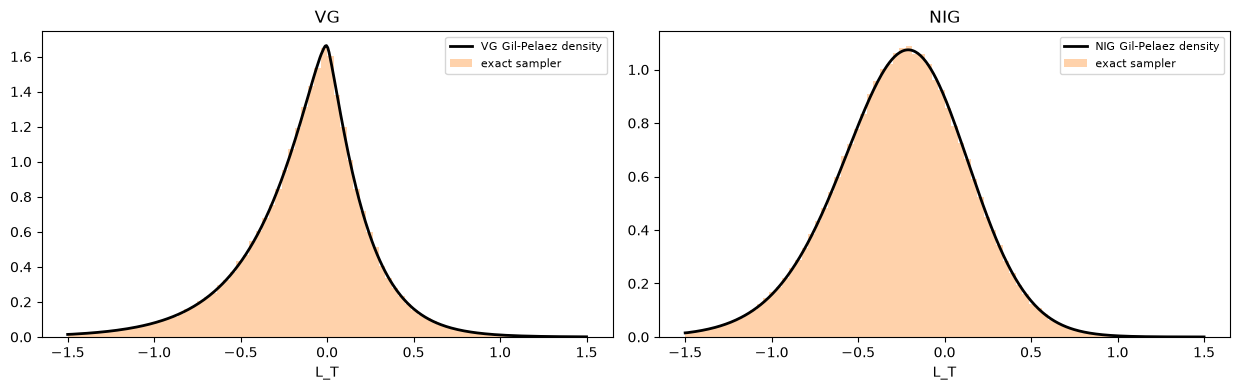

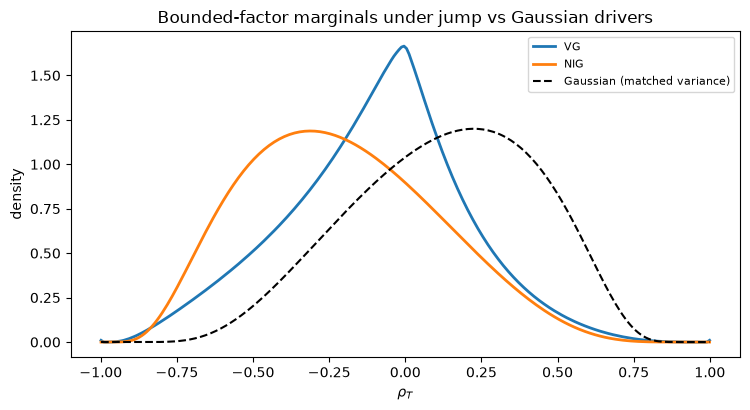

digital 1{rho_T >= 0.5} (undiscounted):
  VG: exact 0.02018  MC 0.01989 (0.00025)
  NIG: exact 0.01257  MC 0.01222 (0.00020)

In [2]:
rng = np.random.default_rng(SEED)
samples = {
    "VG": p11.sample_vg(MATURITY, VG, 300000, rng),
    "NIG": p11.sample_nig(MATURITY, NIGP, 300000, rng),
}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
for ax, (name, params) in zip(axes, [("VG", VG), ("NIG", NIGP)]):
    xs = np.linspace(-1.5, 1.5, 400)
    cdf = np.array([p11.gil_pelaez_cdf(float(x), params.exponent,
                                       maturity=MATURITY) for x in xs])
    density = np.gradient(cdf, xs)
    ax.plot(xs, density, "k-", lw=2, label=f"{name} Gil-Pelaez density")
    hist, edges = np.histogram(samples[name], bins=80, range=(-1.5, 1.5),
                               density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.bar(centers, hist, width=np.diff(edges), alpha=0.35, color="C1",
           label="exact sampler")
    ax.set_title(name); ax.set_xlabel("L_T"); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase11_driver_laws.png", dpi=150)
plt.show()

# Bounded-factor marginal densities
rho_grid = np.linspace(-0.999, 0.999, 240)
x_of = lambda r: SCALE * r / math.sqrt(1 - r**2)
fig, ax = plt.subplots(figsize=(7.6, 4.2))
for name, params in [("VG", VG), ("NIG", NIGP)]:
    dens = []
    for r in rho_grid:
        xt = x_of(r)
        cdf_hi = p11.gil_pelaez_cdf(xt + 0.004, params.exponent, maturity=MATURITY)
        cdf_lo = p11.gil_pelaez_cdf(xt - 0.004, params.exponent, maturity=MATURITY)
        jac = SCALE / (1 - r * r) ** 1.5
        dens.append((cdf_hi - cdf_lo) / 0.008 * jac)
    ax.plot(rho_grid, dens, lw=2, label=name)
# Gaussian reference from Phase 6/7 machinery
from scipy.stats import norm
g_dens = [p7.rho_transition_density_inhom(
    float(r), start=0.0, maturity=MATURITY, rho_start=X0 / math.sqrt(X0**2+SCALE**2)
    if X0 != 0 else 0.0, scale=SCALE, drift=lambda t: DRIFT,
    volatility=lambda t: math.sqrt(VG.sigma**2)) for r in rho_grid]
ax.plot(rho_grid, g_dens, "k--", lw=1.5, label="Gaussian (matched variance)")
ax.set_xlabel(r"$\rho_T$"); ax.set_ylabel("density")
ax.set_title("Bounded-factor marginals under jump vs Gaussian drivers")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase11_rho_marginals.png", dpi=150)
plt.show()

# Exact digitals under each driver
print("digital 1{rho_T >= 0.5} (undiscounted):")
for name, exponent in [("VG", VG.exponent), ("NIG", NIGP.exponent)]:
    price = p11.digital_price_levy(0.5, maturity=MATURITY, x0=X0,
                                   scale=SCALE, rate=0.0, exponent=exponent)
    mc = float(np.mean(samples[name] / np.sqrt(samples[name]**2 + SCALE**2) >= 0.5))
    se = math.sqrt(mc * (1 - mc) / samples[name].size)
    print(f"  {name}: exact {price:.5f}  MC {mc:.5f} ({se:.5f})")

## 2. The clock characteristic function across drivers

(\_A()=E\[e^{iA_T}\]) from the FK-PIDE for the two jump drivers and the Gaussian baseline (Phase-7 forward-FK, variance- matched). Monte Carlo benchmarks use coarse-path trapezoids over exact increments.

In [3]:
xi_grid = np.array([0.5, 1.0, 2.0, 3.0])

def phi_gaussian(xi):
    return p7.fk_characteristic_inhom(
        float(xi), maturity=MATURITY, x0=X0,
        drift=lambda t: DRIFT,
        volatility=lambda t: math.sqrt(VG.sigma**2 + 2*abs(VG.theta)/max(VG.nu,1e-9)*0 +
                                       (VG.sigma**2 + VG.nu*VG.theta**2)),
        scale=SCALE, n_steps=300, n_grid=800)

# variance-matched Gaussian sd:
var_vg = VG.sigma**2 + VG.nu * VG.theta**2
sig_g = math.sqrt(var_vg)
phi_gs = [p7.fk_characteristic_inhom(
    float(xi), maturity=MATURITY, x0=X0, drift=lambda t: DRIFT,
    volatility=lambda t: sig_g, scale=SCALE, n_steps=300, n_grid=800)
    for xi in xi_grid]

phi_vg = [p11.fk_characteristic_levy(
    float(xi), maturity=MATURITY, x0=X0, drift=DRIFT, params=VG,
    scale=SCALE, n_steps=200, n_grid=1200, margin_scale=12.0)
    for xi in xi_grid]
phi_nig = [p11.fk_characteristic_levy(
    float(xi), maturity=MATURITY, x0=X0, drift=DRIFT, params=NIGP,
    scale=SCALE, n_steps=200, n_grid=1200, margin_scale=12.0)
    for xi in xi_grid]

# MC benchmarks (coarse trapezoid clocks, exact increments)
n_paths, n_steps = 60000, 250
dt = MATURITY / n_steps
def mc_phi(params, sampler):
    Lacc = np.zeros(n_paths)
    acc = np.zeros(n_paths)
    prev = X0 / math.sqrt(X0**2 + SCALE**2) if X0 != 0 else 0.0
    for k in range(n_steps):
        Lacc = Lacc + DRIFT * dt + sampler(dt, params, n_paths, rng)
        cur = Lacc / np.sqrt(Lacc**2 + SCALE**2)
        acc += 0.5 * (prev + cur) * dt
        prev = cur
    return [complex(np.mean(np.cos(xi * acc)), np.mean(np.sin(xi * acc)))
            for xi in xi_grid], acc

phi_vg_mc, acc_vg = mc_phi(VG, p11.sample_vg)
phi_nig_mc, acc_nig = mc_phi(NIGP, p11.sample_nig)

print("xi | Gaussian | VG PIDE (MC) | NIG PIDE (MC)")
for i, xi in enumerate(xi_grid):
    print(f"{xi:.1f} | {phi_gs[i].real:+.4f}{phi_gs[i].imag:+.4f}j | "
          f"{phi_vg[i].real:+.4f}{phi_vg[i].imag:+.4f}j "
          f"({phi_vg_mc[i].real:+.4f}{phi_vg_mc[i].imag:+.4f}j) | "
          f"{phi_nig[i].real:+.4f}{phi_nig[i].imag:+.4f}j "
          f"({phi_nig_mc[i].real:+.4f}{phi_nig_mc[i].imag:+.4f}j)")

se_vg = float(np.std(np.cos(3.0 * acc_vg)) / math.sqrt(n_paths))
ok = abs(phi_vg[-1].real - phi_vg_mc[-1].real) <= 5 * se_vg
print(f"\nlargest-xi VG real-part check vs MC (5 SE = {5*se_vg:.4f}): {'OK' if ok else 'FAIL'}")

xi | Gaussian | VG PIDE (MC) | NIG PIDE (MC)
0.5 | +0.9949+0.0334j | +0.9960+0.0092j (+0.9960+0.0087j) | +0.9948-0.0243j (+0.9949-0.0220j)
1.0 | +0.9796+0.0660j | +0.9841+0.0187j (+0.9840+0.0177j) | +0.9793-0.0478j (+0.9798-0.0432j)
2.0 | +0.9204+0.1255j | +0.9384+0.0388j (+0.9383+0.0369j) | +0.9196-0.0895j (+0.9214-0.0807j)
3.0 | +0.8284+0.1729j | +0.8685+0.0612j (+0.8685+0.0586j) | +0.8275-0.1201j (+0.8313-0.1081j)

largest-xi VG real-part check vs MC (5 SE = 0.0043): OK

## 3. Clock distributions: how jumps reshape correlation-risk timing

Fourier inversion of (\_A()) on a real grid gives the (A_T) density under each driver — deterministic for all three.

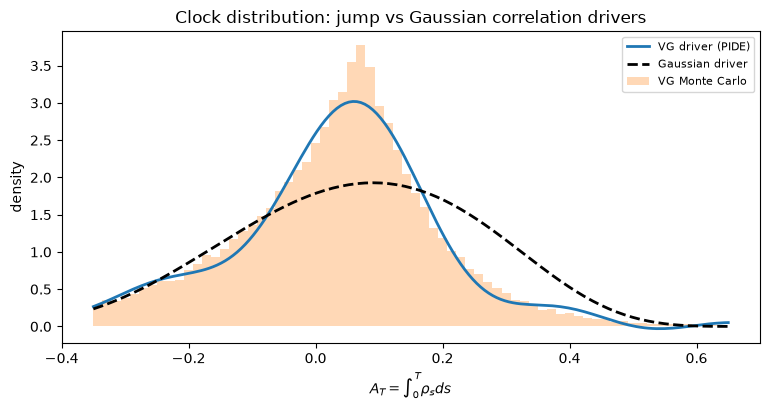

E[A_T]: VG 0.0350  Gaussian 0.0730

In [4]:
a_grid = np.linspace(-0.35, 0.65, 160)
T_ref = MATURITY

def clock_density_from_cf(phis, xis):
    # gil-pelaez-style inversion on the precomputed CF grid
    dens = []
    for a in a_grid:
        integ = np.real(np.exp(-1j * xis * a) * np.asarray(phis))
        dens.append(np.trapezoid(integ, xis) / math.pi)
    return np.array(dens)

xi_fine = np.linspace(1e-4, 24.0, 900)
phis_vg = np.array([p11.fk_characteristic_levy(
    float(xi), maturity=T_ref, x0=X0, drift=DRIFT, params=VG,
    scale=SCALE, n_steps=120, n_grid=900, margin_scale=12.0)
    for xi in xi_fine])
phis_gauss = np.array([p7.fk_characteristic_inhom(
    float(xi), maturity=T_ref, x0=X0, drift=lambda t: DRIFT,
    volatility=lambda t: sig_g, scale=SCALE, n_steps=150, n_grid=600)
    for xi in xi_fine])

dens_vg = clock_density_from_cf(phis_vg, xi_fine)
dens_gauss = clock_density_from_cf(phis_gauss, xi_fine)

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.plot(a_grid, dens_vg, lw=2, label="VG driver (PIDE)")
ax.plot(a_grid, dens_gauss, "k--", lw=2, label="Gaussian driver")
hist, edges = np.histogram(acc_vg, bins=70, range=(a_grid[0], a_grid[-1]),
                           density=True)
ax.bar(0.5 * (edges[:-1] + edges[1:]), hist, width=np.diff(edges),
       alpha=0.3, color="C1", label="VG Monte Carlo")
ax.set_xlabel(r"$A_T=\int_0^T\rho_s ds$"); ax.set_ylabel("density")
ax.set_title("Clock distribution: jump vs Gaussian correlation drivers")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "phase11_clock_densities.png", dpi=150)
plt.show()

mean_vg = float(np.trapezoid(a_grid * dens_vg, a_grid))
mean_g = float(np.trapezoid(a_grid * dens_gauss, a_grid))
print(f"E[A_T]: VG {mean_vg:.4f}  Gaussian {mean_g:.4f}")

## 4. Record

Deterministic path: Gil–Pelaez marginals, FK-PIDE clock transforms, Fourier-inverted clock densities. Monte Carlo only as benchmark. Figures in `phase11_figures/`.

In [5]:
elapsed = time.time() - started
print(f"notebook executed in {elapsed:.1f} s")

notebook executed in 319.2 s